# 📦 Feature Engineering

> **Folder:** `01_Data_Preprocessing / Feature_Engineering`  
> **Notebook:** `feature_engineering.ipynb`  
> **Author:** Hamna Munir

---

## 🎯 Objectives

By the end of this notebook, you will:

- Understand **what feature engineering is** and why it matters
- Apply **10 feature engineering techniques** with hands-on examples
- **Visualize** the impact of new features on target correlation
- Know the correct **pipeline order** for feature engineering
- Avoid critical mistakes like **data leakage** in group aggregations

---

## 📚 Techniques Covered

| # | Technique | What It Does |
|---|-----------|-------------|
| 1 | Ratio Features | numerator / denominator |
| 2 | Difference Features | col_a - col_b |
| 3 | Log Transformation | Reduce right skew |
| 4 | Polynomial & Interaction | Non-linear cross terms |
| 5 | Date & Time Features | Year, Month, DayOfWeek, cyclic |
| 6 | Text-Based Features | Length, word count, patterns |
| 7 | Group Aggregation | Group mean, std, deviation |
| 8 | Binning / Discretization | Continuous → categorical bins |
| 9 | Flag / Indicator Features | Binary conditions |
| 10 | Feature-Target Correlation | Rank new features by impact |

---
## ⚙️ 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


---
## 📊 1. Load & Explore Dataset

In [2]:
# ── Synthetic Dataset ────────────────────────────────────────────────────
np.random.seed(42)
n = 400

data = {
    'Age'        : np.random.randint(20, 65, n),
    'Salary'     : np.random.randint(30_000, 150_000, n),
    'Expenses'   : np.random.randint(10_000, 80_000, n),
    'Score_Pre'  : np.random.randint(40, 80, n),
    'Score_Post' : np.random.randint(50, 100, n),
    'City'       : np.random.choice(['London', 'Paris', 'Berlin', 'Tokyo'], n),
    'JoinDate'   : pd.date_range('2018-01-01', periods=n, freq='2D'),
    'Description': ['Great product, highly recommend!' if i % 2 == 0
                    else 'Terrible experience, avoid at all costs.' for i in range(n)],
    'Income'     : np.random.exponential(50_000, n),
    'Target'     : np.random.randint(0, 2, n),
}

df = pd.DataFrame(data)
print(f'Shape: {df.shape}')
df.head()

Shape: (400, 10)


,Age,Salary,Expenses,Score_Pre,Score_Post,City,JoinDate,Description,Income,Target
0,58,144692,75545,67,96,Tokyo,2018-01-01,"Great product, highly recommend!",29638.1801,1
1,48,117142,68141,47,64,Paris,2018-01-03,"Terrible experience, avoid at all costs.",45888.8835,1
2,34,117235,33793,73,81,London,2018-01-05,"Great product, highly recommend!",36250.4126,1
3,62,84021,66570,74,60,Tokyo,2018-01-07,"Terrible experience, avoid at all costs.",125907.8523,0
4,27,96412,47892,71,72,London,2018-01-09,"Great product, highly recommend!",34354.6256,1


In [3]:
# ── Data Types Overview ──────────────────────────────────────────────────
print('Data Types:')
print(df.dtypes)
print(f'\nNumeric columns : {df.select_dtypes(include="number").columns.tolist()}')
print(f'Object columns  : {df.select_dtypes(include="object").columns.tolist()}')
print(f'Datetime columns: {df.select_dtypes(include="datetime").columns.tolist()}')

Data Types:
Age                     int64
Salary                  int64
Expenses                int64
Score_Pre               int64
Score_Post              int64
City                   object
JoinDate       datetime64[ns]
Description            object
Income                float64
Target                  int64
dtype: object

Numeric columns : ['Age', 'Salary', 'Expenses', 'Score_Pre', 'Score_Post', 'Income', 'Target']
Object columns  : ['City', 'Description']
Datetime columns: ['JoinDate']


In [4]:
# ── Train-Test Split — ALWAYS before feature engineering! ────────────────
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {train_df.shape} | Test: {test_df.shape}')
print('✅ Split done — group features will be computed on train only!')

Train: (320, 10) | Test: (80, 10)
✅ Split done — group features will be computed on train only!


---
## 1️⃣ Ratio Features

> **Formula:** `new_feature = numerator / denominator`
>
> ✅ Captures relative relationships — profit margin, savings rate, efficiency ratios.

In [5]:
train_df['Savings_Rate']   = train_df['Salary'] / (train_df['Expenses'] + 1e-10)
test_df['Savings_Rate']    = test_df['Salary']  / (test_df['Expenses']  + 1e-10)

train_df['Salary_Per_Age'] = train_df['Salary'] / (train_df['Age'] + 1e-10)
test_df['Salary_Per_Age']  = test_df['Salary']  / (test_df['Age']  + 1e-10)

print('New ratio features added:')
train_df[['Salary', 'Expenses', 'Savings_Rate', 'Age', 'Salary_Per_Age']].head()

New ratio features added:


,Salary,Expenses,Savings_Rate,Age,Salary_Per_Age
0,84021,66570,1.2621,62,1355.1774
1,113613,18702,6.0749,43,2642.1628
2,30728,30618,1.0036,47,653.7872
3,36801,44016,0.8361,44,836.3864
4,43807,77779,0.5632,43,1018.7674


---
## 2️⃣ Difference Features

> **Formula:** `new_feature = col_a - col_b`
>
> ✅ Captures improvement, gap, or elapsed time between two related features.

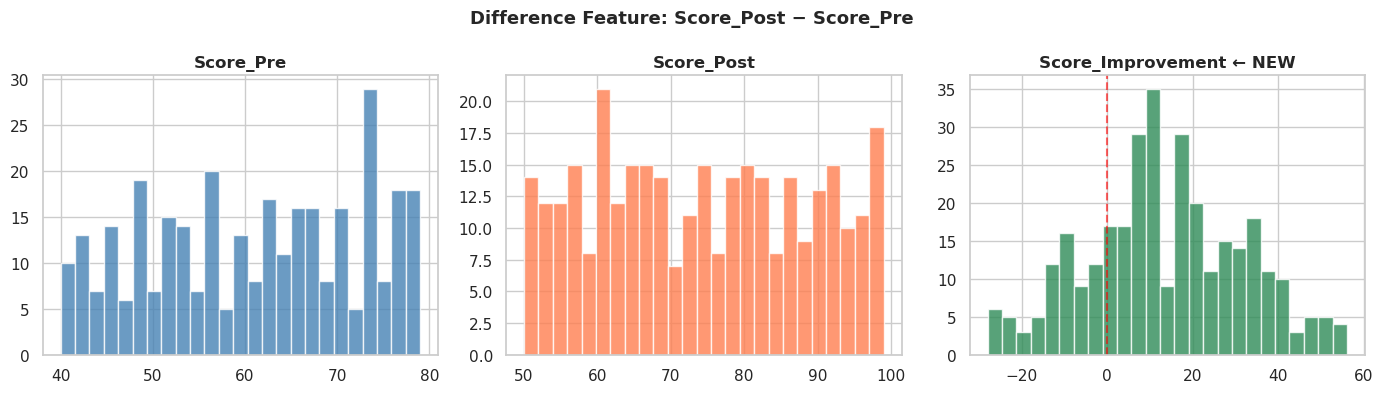

Positive improvement: 246 rows


In [6]:
train_df['Score_Improvement'] = train_df['Score_Post'] - train_df['Score_Pre']
test_df['Score_Improvement']  = test_df['Score_Post']  - test_df['Score_Pre']

# ── Visualize distribution of new feature ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(train_df['Score_Pre'],         bins=25, color='steelblue',  edgecolor='white', alpha=0.8)
axes[0].set_title('Score_Pre',              fontweight='bold')
axes[1].hist(train_df['Score_Post'],        bins=25, color='coral',      edgecolor='white', alpha=0.8)
axes[1].set_title('Score_Post',             fontweight='bold')
axes[2].hist(train_df['Score_Improvement'], bins=25, color='seagreen',   edgecolor='white', alpha=0.8)
axes[2].set_title('Score_Improvement ← NEW', fontweight='bold')
axes[2].axvline(0, color='red', linestyle='--', alpha=0.6)

plt.suptitle('Difference Feature: Score_Post − Score_Pre', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Positive improvement: {(train_df["Score_Improvement"] > 0).sum()} rows')

---
## 3️⃣ Log Transformation

> **Formula:** `X_new = log(X + 1)`
>
> ✅ Reduces right skewness — especially useful for income, salary, price features.

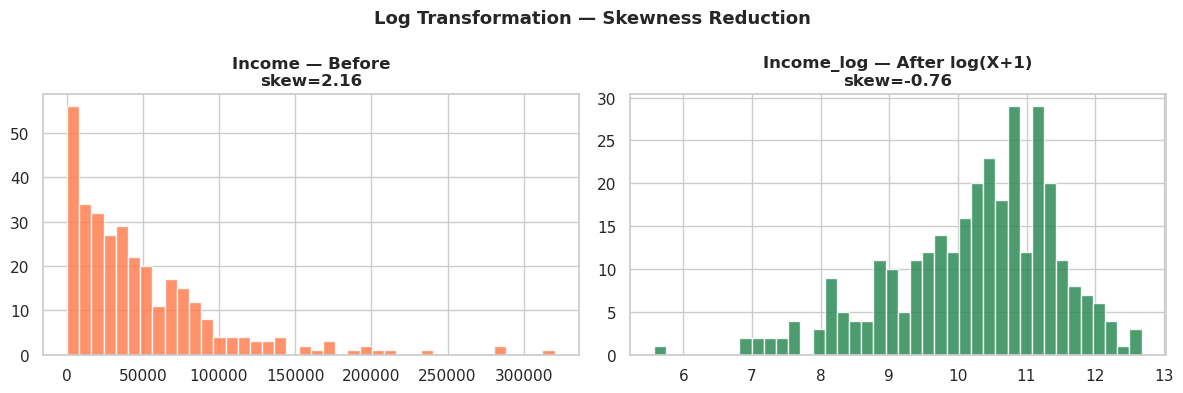

In [7]:
train_df['Income_log'] = np.log1p(train_df['Income'])
test_df['Income_log']  = np.log1p(test_df['Income'])

train_df['Salary_log'] = np.log1p(train_df['Salary'])
test_df['Salary_log']  = np.log1p(test_df['Salary'])

# ── Before vs After ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['Income'],     bins=40, color='coral',    edgecolor='white', alpha=0.85)
axes[0].set_title(f'Income — Before\nskew={train_df["Income"].skew():.2f}', fontweight='bold')

axes[1].hist(train_df['Income_log'], bins=40, color='seagreen', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Income_log — After log(X+1)\nskew={train_df["Income_log"].skew():.2f}', fontweight='bold')

plt.suptitle('Log Transformation — Skewness Reduction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4️⃣ Polynomial & Interaction Features

> **Formula (degree=2, [a, b]):** `[a, b, a², a·b, b²]`
>
> ⚠️ Can cause dimensionality explosion — use `interaction_only=True` to limit cross terms.

In [8]:
cols = ['Age', 'Score_Pre']

poly = PolynomialFeatures(degree=2, include_bias=False)
train_poly = poly.fit_transform(train_df[cols])
test_poly  = poly.transform(test_df[cols])

feature_names = poly.get_feature_names_out(cols)
print(f'Original features : {cols}')
print(f'After degree=2    : {list(feature_names)}')

train_poly_df = pd.DataFrame(train_poly, columns=feature_names, index=train_df.index)
test_poly_df  = pd.DataFrame(test_poly,  columns=feature_names, index=test_df.index)

# Merge back (avoid duplicating original cols)
new_poly_cols = [f for f in feature_names if f not in cols]
train_df = train_df.join(train_poly_df[new_poly_cols])
test_df  = test_df.join(test_poly_df[new_poly_cols])

print(f'\nNew features added: {new_poly_cols}')
train_df[new_poly_cols].head()

Original features : ['Age', 'Score_Pre']
After degree=2    : ['Age', 'Score_Pre', 'Age^2', 'Age Score_Pre', 'Score_Pre^2']

New features added: ['Age^2', 'Age Score_Pre', 'Score_Pre^2']


,Age^2,Age Score_Pre,Score_Pre^2
0,3844.0000,4588.0000,5476.0000
1,1849.0000,3096.0000,5184.0000
2,2209.0000,2444.0000,2704.0000
3,1936.0000,2816.0000,4096.0000
4,1849.0000,3311.0000,5929.0000


---
## 5️⃣ Date & Time Features

> Extract **Year, Month, DayOfWeek, Quarter, IsWeekend** and more from datetime columns.
>
> ✅ Use **cyclic encoding** (sin/cos) for Month and DayOfWeek — captures circular nature of time.

In [10]:
def extract_datetime_features(df, date_col):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    dt = df[date_col].dt
    df[f'{date_col}_Year']          = dt.year
    df[f'{date_col}_Month']         = dt.month
    df[f'{date_col}_Day']           = dt.day
    df[f'{date_col}_DayOfWeek']     = dt.dayofweek
    df[f'{date_col}_Quarter']       = dt.quarter
    df[f'{date_col}_IsWeekend']     = (dt.dayofweek >= 5).astype(int)
    df[f'{date_col}_IsMonthStart']  = dt.is_month_start.astype(int)
    df[f'{date_col}_IsMonthEnd']    = dt.is_month_end.astype(int)
    df[f'{date_col}_Days_Since'] = (df[date_col] - df[date_col].min()).dt.days
    # Cyclic encoding
    df[f'{date_col}_Month_sin']     = np.sin(2 * np.pi * dt.month     / 12)
    df[f'{date_col}_Month_cos']     = np.cos(2 * np.pi * dt.month     / 12)
    df[f'{date_col}_DayOfWeek_sin'] = np.sin(2 * np.pi * dt.dayofweek / 7)
    df[f'{date_col}_DayOfWeek_cos'] = np.cos(2 * np.pi * dt.dayofweek / 7)
    return df

train_df = extract_datetime_features(train_df, 'JoinDate')
test_df  = extract_datetime_features(test_df,  'JoinDate')

dt_cols = [c for c in train_df.columns if c.startswith('JoinDate_')]
print(f'{len(dt_cols)} datetime features extracted:')
print(dt_cols)
train_df[dt_cols].head()

13 datetime features extracted:
['JoinDate_Year', 'JoinDate_Month', 'JoinDate_Day', 'JoinDate_DayOfWeek', 'JoinDate_Quarter', 'JoinDate_IsWeekend', 'JoinDate_IsMonthStart', 'JoinDate_IsMonthEnd', 'JoinDate_Days_Since', 'JoinDate_Month_sin', 'JoinDate_Month_cos', 'JoinDate_DayOfWeek_sin', 'JoinDate_DayOfWeek_cos']


,JoinDate_Year,JoinDate_Month,JoinDate_Day,JoinDate_DayOfWeek,JoinDate_Quarter,JoinDate_IsWeekend,JoinDate_IsMonthStart,JoinDate_IsMonthEnd,JoinDate_Days_Since,JoinDate_Month_sin,JoinDate_Month_cos,JoinDate_DayOfWeek_sin,JoinDate_DayOfWeek_cos
0,2018,1,7,6,1,1,0,0,4,0.5000,0.8660,-0.7818,0.6235
1,2018,2,6,1,1,0,0,0,34,0.8660,0.5000,0.7818,0.6235
2,2019,2,9,5,1,1,0,0,402,0.8660,0.5000,-0.9749,-0.2225
3,2019,5,16,3,2,0,0,0,498,0.5000,-0.8660,0.4339,-0.9010
4,2019,7,3,2,3,0,0,0,546,-0.5000,-0.8660,0.9749,-0.2225


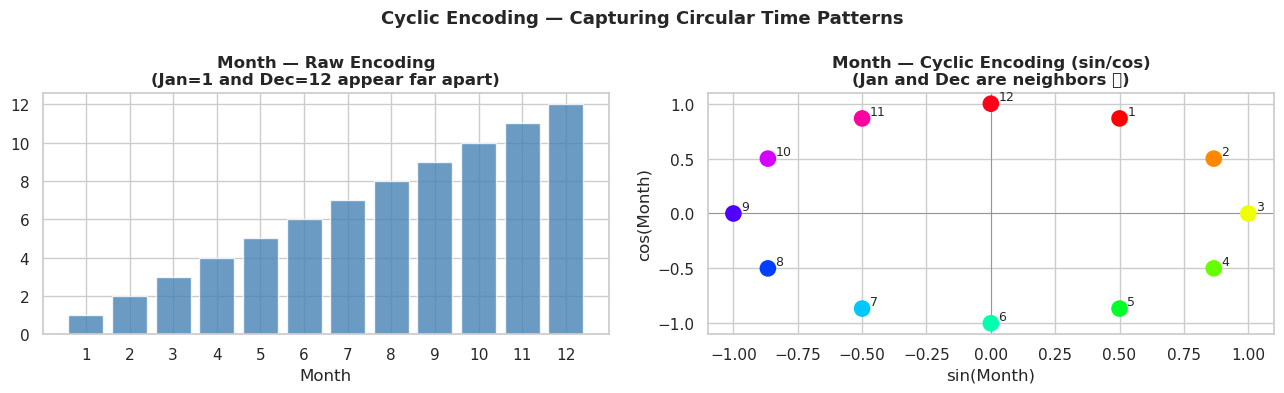

In [11]:
# ── Visualize Cyclic Encoding ─────────────────────────────────────────────
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(months, months, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Month — Raw Encoding\n(Jan=1 and Dec=12 appear far apart)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_xticks(months)

axes[1].scatter(month_sin, month_cos, c=months, cmap='hsv', s=120, zorder=5)
for i, m in enumerate(months):
    axes[1].annotate(str(m), (month_sin[i]+0.03, month_cos[i]+0.03), fontsize=9)
axes[1].set_title('Month — Cyclic Encoding (sin/cos)\n(Jan and Dec are neighbors ✅)', fontweight='bold')
axes[1].set_xlabel('sin(Month)')
axes[1].set_ylabel('cos(Month)')
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].axvline(0, color='gray', lw=0.5)

plt.suptitle('Cyclic Encoding — Capturing Circular Time Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6️⃣ Text-Based Features

> Convert string columns into **numeric signals** — character count, word count, patterns.
>
> ✅ Quick wins before applying full NLP (TF-IDF, embeddings).

In [12]:
for _df in [train_df, test_df]:
    col = _df['Description'].astype(str).fillna('')
    _df['Desc_char_length']   = col.str.len()
    _df['Desc_word_count']    = col.str.split().str.len()
    _df['Desc_unique_words']  = col.apply(lambda x: len(set(x.lower().split())))
    _df['Desc_avg_word_len']  = col.apply(
        lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    _df['Desc_num_uppercase'] = col.str.count(r'[A-Z]')
    _df['Desc_has_special']   = col.str.contains(r'[^a-zA-Z0-9\s]').astype(int)

text_cols = ['Desc_char_length','Desc_word_count','Desc_unique_words',
             'Desc_avg_word_len','Desc_num_uppercase','Desc_has_special']

print('Text Features:')
train_df[['Description'] + text_cols].head()

Text Features:


,Description,Desc_char_length,Desc_word_count,Desc_unique_words,Desc_avg_word_len,Desc_num_uppercase,Desc_has_special
0,"Terrible experience, avoid at all costs.",40,6,6,5.8333,1,1
1,"Great product, highly recommend!",32,4,4,7.2500,1,1
2,"Great product, highly recommend!",32,4,4,7.2500,1,1
3,"Great product, highly recommend!",32,4,4,7.2500,1,1
4,"Great product, highly recommend!",32,4,4,7.2500,1,1


---
## 7️⃣ Group Aggregation Features

> Replace categorical groups with **group-level statistics** (mean, std, count).
>
> ⚠️ Always compute on **train only** then map to test — prevents data leakage!

In [13]:
group_col, agg_col = 'City', 'Salary'

for func in ['mean', 'median', 'std', 'max', 'min', 'count']:
    col_name = f'{group_col}_{agg_col}_{func}'
    stat_map  = train_df.groupby(group_col)[agg_col].agg(func)
    train_df[col_name] = train_df[group_col].map(stat_map)   # map from train stats
    test_df[col_name]  = test_df[group_col].map(stat_map)    # apply same map to test

# Deviation from group mean
train_df['Salary_vs_City_mean'] = train_df['Salary'] - train_df['City_Salary_mean']
test_df['Salary_vs_City_mean']  = test_df['Salary']  - test_df['City_Salary_mean']

group_agg_cols = [c for c in train_df.columns if c.startswith(f'{group_col}_{agg_col}')]
group_agg_cols.append('Salary_vs_City_mean')

print('Group Aggregation Features:')
train_df[['City', 'Salary'] + group_agg_cols].head(8)

Group Aggregation Features:


,City,Salary,City_Salary_mean,City_Salary_median,City_Salary_std,City_Salary_max,City_Salary_min,City_Salary_count,Salary_vs_City_mean
0,Tokyo,84021,91046.7976,89630.5000,33686.2277,148874,30728,84,-7025.7976
1,Tokyo,113613,91046.7976,89630.5000,33686.2277,148874,30728,84,22566.2024
2,Tokyo,30728,91046.7976,89630.5000,33686.2277,148874,30728,84,-60318.7976
3,Paris,36801,89580.7857,91459.0000,31286.0348,149180,33709,84,-52779.7857
4,Berlin,43807,84686.0294,83417.0000,36458.3345,148012,30412,68,-40879.0294
5,Tokyo,43284,91046.7976,89630.5000,33686.2277,148874,30728,84,-47762.7976
6,Paris,132634,89580.7857,91459.0000,31286.0348,149180,33709,84,43053.2143
7,Tokyo,34748,91046.7976,89630.5000,33686.2277,148874,30728,84,-56298.7976


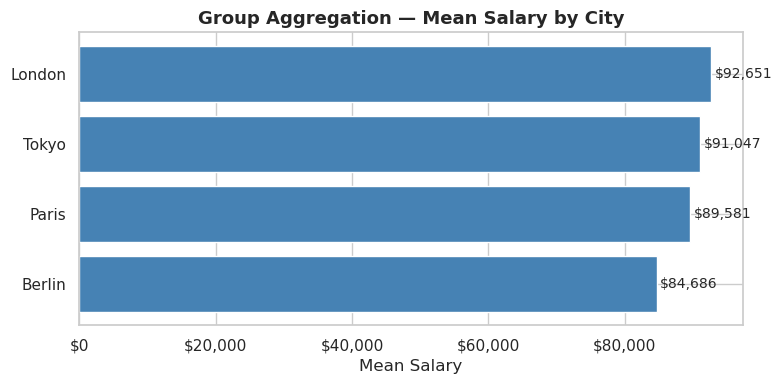

In [14]:
# ── Visualize mean salary per city ───────────────────────────────────────
city_means = train_df.groupby('City')['Salary'].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(city_means.index, city_means.values,
               color='steelblue', edgecolor='white')
ax.set_xlabel('Mean Salary')
ax.set_title('Group Aggregation — Mean Salary by City', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, city_means.values):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 8️⃣ Binning / Discretization

> Convert continuous features into **discrete bins** (categories).
>
> ✅ Useful when a non-linear relationship exists between feature and target.

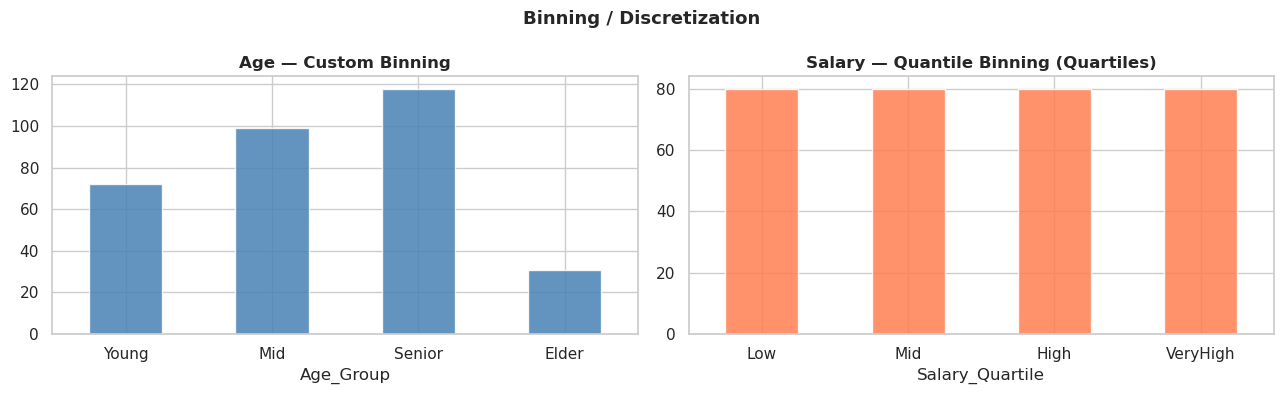

In [15]:
# ── Custom domain-based binning ───────────────────────────────────────────
age_bins   = [0, 30, 45, 60, 100]
age_labels = ['Young', 'Mid', 'Senior', 'Elder']

train_df['Age_Group'] = pd.cut(train_df['Age'], bins=age_bins,
                                labels=age_labels, include_lowest=True)
test_df['Age_Group']  = pd.cut(test_df['Age'],  bins=age_bins,
                                labels=age_labels, include_lowest=True)

# ── Quantile binning ─────────────────────────────────────────────────────
train_df['Salary_Quartile'] = pd.qcut(train_df['Salary'], q=4,
                                       labels=['Low','Mid','High','VeryHigh'],
                                       duplicates='drop')
test_df['Salary_Quartile']  = pd.qcut(test_df['Salary'],  q=4,
                                       labels=['Low','Mid','High','VeryHigh'],
                                       duplicates='drop')

# ── Visualize ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_df['Age_Group'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Age — Custom Binning', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

train_df['Salary_Quartile'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white', alpha=0.85)
axes[1].set_title('Salary — Quantile Binning (Quartiles)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Binning / Discretization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9️⃣ Flag / Indicator Features

> Create **binary (0/1) flags** from domain-defined conditions.
>
> ✅ Also use to flag missing values as a feature — missingness can be a pattern.

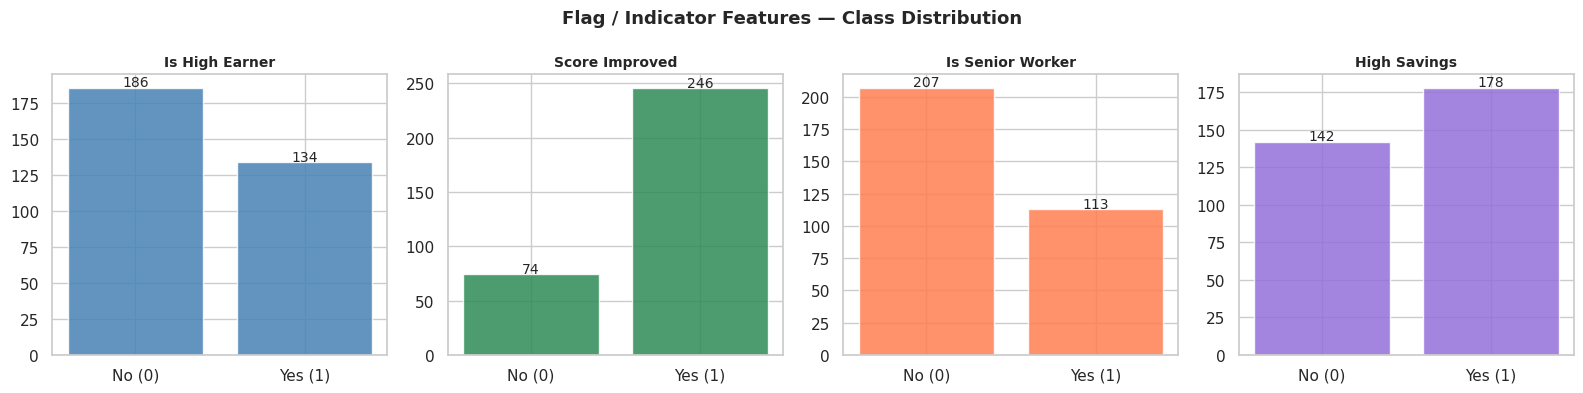

,Is_High_Earner,Score_Improved,Is_Senior_Worker,High_Savings
0,0,0,1,0
1,1,1,0,1
2,0,1,0,0
3,0,1,0,0
4,0,0,0,0


In [16]:
# ── Domain flags ─────────────────────────────────────────────────────────
for _df in [train_df, test_df]:
    _df['Is_High_Earner']   = (_df['Salary']           > 100_000).astype(int)
    _df['Score_Improved']   = (_df['Score_Improvement'] > 0).astype(int)
    _df['Is_Senior_Worker'] = (_df['Age']               > 50).astype(int)
    _df['High_Savings']     = (_df['Savings_Rate']      > 2.0).astype(int)

flag_cols = ['Is_High_Earner', 'Score_Improved', 'Is_Senior_Worker', 'High_Savings']

# ── Visualize flag distributions ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

for ax, col, color in zip(axes, flag_cols, colors):
    counts = train_df[col].value_counts().sort_index()
    ax.bar(['No (0)', 'Yes (1)'], counts.values, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' '), fontsize=10, fontweight='bold')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=10)

plt.suptitle('Flag / Indicator Features — Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

train_df[flag_cols].head()

---
## 📊 10. Feature-Target Correlation Analysis

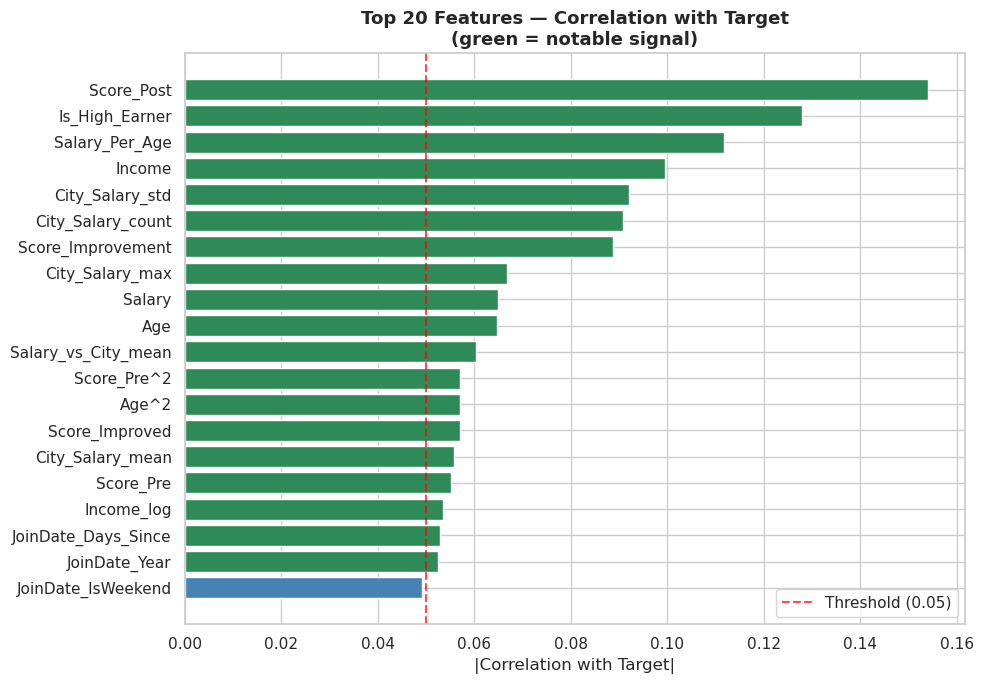

In [17]:
# ── Correlation of all numeric features with Target ───────────────────────
num_train = train_df.select_dtypes(include=np.number)
corr_with_target = (
    num_train.corr()['Target']
    .drop('Target')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['seagreen' if v > 0.05 else 'steelblue' for v in corr_with_target.values]
bars = ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1],
               color=colors[::-1], edgecolor='white')
ax.axvline(0.05, color='red', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Threshold (0.05)')
ax.set_xlabel('|Correlation with Target|', fontsize=12)
ax.set_title('Top 20 Features — Correlation with Target\n(green = notable signal)',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 📊 11. Impact of Feature Engineering on Model Performance

Baseline (original)           : Accuracy = 0.4500
Engineered Features           : Accuracy = 0.5125


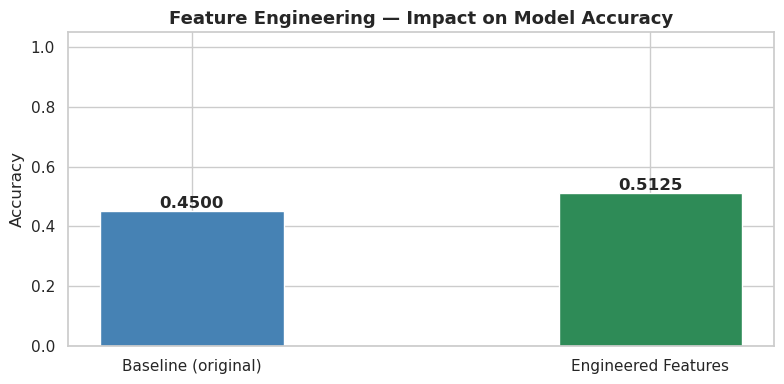

In [18]:
from sklearn.pipeline import Pipeline

# ── Baseline: original numeric features only ──────────────────────────────
base_cols     = ['Age', 'Salary', 'Expenses', 'Score_Pre', 'Score_Post', 'Income']
eng_cols      = base_cols + [
    'Savings_Rate', 'Salary_Per_Age', 'Score_Improvement',
    'Income_log', 'Salary_log',
    'Is_High_Earner', 'Score_Improved', 'Is_Senior_Worker',
    'City_Salary_mean', 'City_Salary_std', 'Salary_vs_City_mean',
    'JoinDate_Month_sin', 'JoinDate_Month_cos',
    'Desc_word_count', 'Desc_char_length',
]

y_train = train_df['Target']
y_test  = test_df['Target']

results = {}
for label, cols in [('Baseline (original)', base_cols),
                     ('Engineered Features', eng_cols)]:
    X_tr = train_df[cols].fillna(0)
    X_te = test_df[cols].fillna(0)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    pipe.fit(X_tr, y_train)
    acc = accuracy_score(y_test, pipe.predict(X_te))
    results[label] = round(acc, 4)
    print(f'{label:30s}: Accuracy = {acc:.4f}')

# ── Bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(results.keys(), results.values(),
              color=['steelblue', 'seagreen'], edgecolor='white', width=0.4)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Feature Engineering — Impact on Model Accuracy',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✅ 12. Summary & Best Practices

| Technique | Formula / Idea | Best For |
|-----------|---------------|----------|
| **Ratio Features** | A / B | Relative relationships |
| **Difference Features** | A - B | Improvement, gap, elapsed time |
| **Log Transform** | log(X+1) | Right-skewed features |
| **Polynomial** | X², X·Y | Non-linear patterns |
| **Datetime Features** | Year, Month, sin/cos | Temporal signals |
| **Text Features** | length, word count | String columns |
| **Group Aggregation** | mean/std by group | Category + numeric interaction |
| **Binning** | pd.cut / pd.qcut | Non-linear, domain brackets |
| **Flag Features** | condition → 0/1 | Thresholds, missing values |

### 🔑 Golden Rules

1. **Split first, engineer after** — never compute group stats on full data
2. **Fit aggregations on train only** — map the same stats to test
3. **Validate new features** — check correlation with target before keeping
4. **Domain knowledge > algorithms** — the best features come from understanding the problem
5. **Use cyclic encoding** for Month, DayOfWeek, Hour — they are circular
6. **Limit polynomial degree** — degree ≥ 3 causes severe dimensionality explosion
7. **Always track feature count** — more is not always better

---

## 🔗 Next Steps

- ➡️ `Feature_Scaling/` — Scale engineered numeric features
- ➡️ `Train_Test_Split/` — Proper split strategy before engineering
- ➡️ `06_Feature_Selection/` — Select best engineered features, drop noise
- ➡️ `07_Hyperparameter_Tuning/` — Tune models trained on engineered features